In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


## 1️⃣ Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

# Configuration
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

## 2️⃣ Data Loading

In [3]:
# File Paths
file_paths = [
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_0_500000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_500000_1000000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_1000000_1500000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_1500000_1861108.csv"
]

# Load and Concatenate Data
chunk_size = 100000
data = []

print("Loading data...")
for file in file_paths:
    for chunk in pd.read_csv(file, chunksize=chunk_size):
        data.append(chunk)

df = pd.concat(data, ignore_index=True)
print(f"Data Loaded Successfully. Shape: {df.shape}")

# Initial Inspection
display(df.head())

Loading data...
Data Loaded Successfully. Shape: (1861108, 6)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


## 3️⃣ Data Cleaning & Preprocessing

In [4]:
print("--- Data Preprocessing ---")

# 1. Date Conversion
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

# 2. Handle Duplicates
print(f"Duplicates before clean: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# 3. Handle Negative Values (Sanity Check)
neg_vals = (df[['bio_age_5_17', 'bio_age_17_']] < 0).sum().sum()
if neg_vals > 0:
    print(f"Correcting {neg_vals} negative values...")
    df.loc[df['bio_age_17_'] < 0, 'bio_age_17_'] = 0
    df.loc[df['bio_age_5_17'] < 0, 'bio_age_5_17'] = 0

# 4. Cap Outliers (99th Percentile)
upper_cap = df['bio_age_17_'].quantile(0.99)
df['bio_age_17_'] = df['bio_age_17_'].clip(upper=upper_cap)

# 5. Create 'Total Biometric' Column
df['bio_total'] = df['bio_age_5_17'] + df['bio_age_17_']

print("Data Cleaned.")
df.info()

--- Data Preprocessing ---
Duplicates before clean: 331623
Data Cleaned.
<class 'pandas.core.frame.DataFrame'>
Index: 1529485 entries, 0 to 1861106
Data columns (total 10 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   date          871964 non-null   datetime64[ns]
 1   state         1529485 non-null  object        
 2   district      1529485 non-null  object        
 3   pincode       1529485 non-null  int64         
 4   bio_age_5_17  1529485 non-null  int64         
 5   bio_age_17_   1529485 non-null  float64       
 6   year          871964 non-null   float64       
 7   month         871964 non-null   float64       
 8   year_month    1529485 non-null  object        
 9   bio_total     1529485 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 128.4+ MB


## 4️⃣ Exploratory Data Analysis (EDA)

--- Exploratory Data Analysis ---


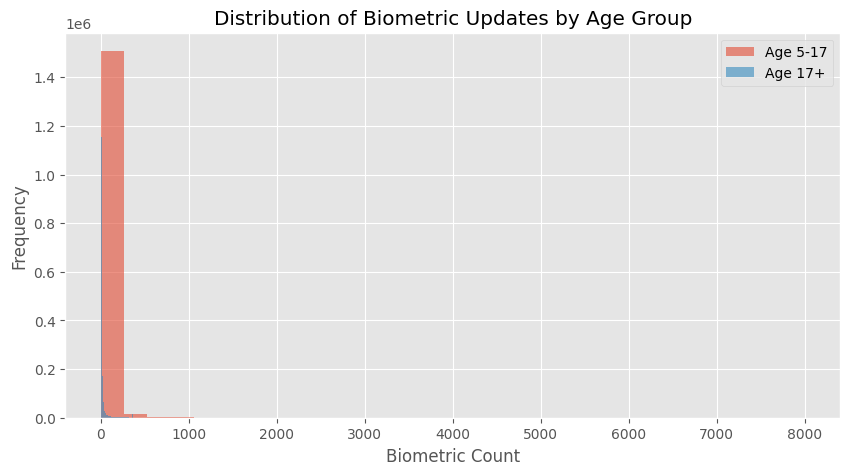

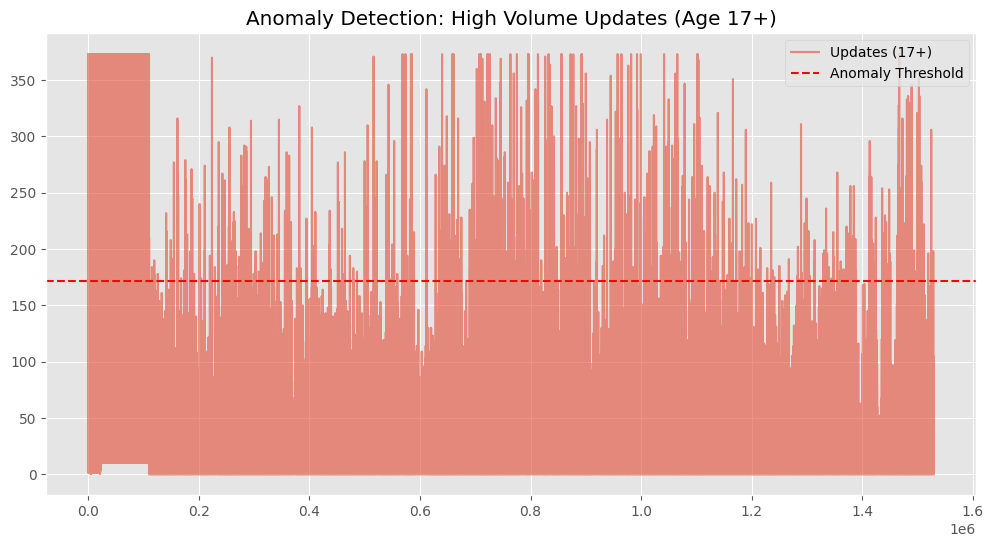

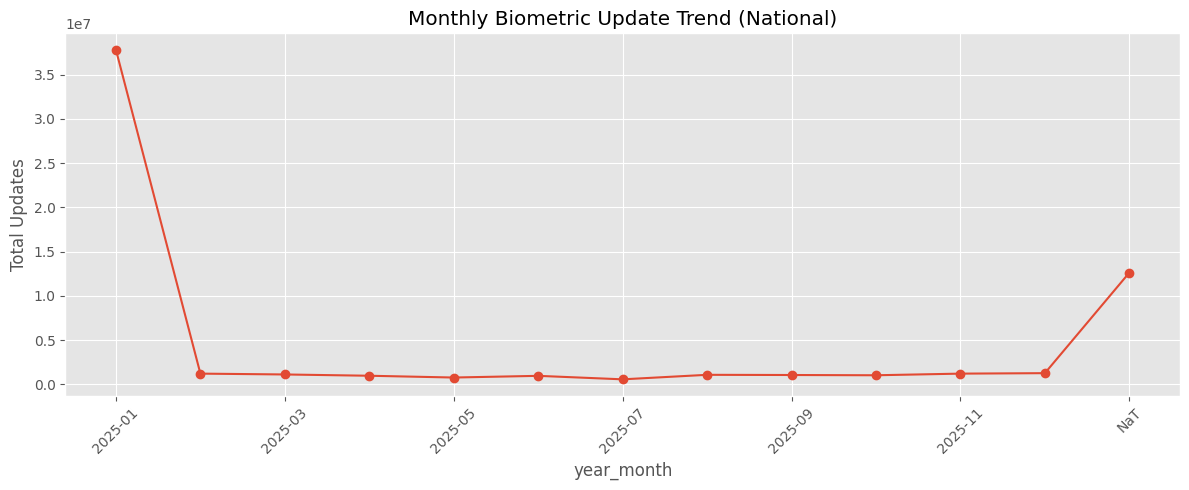

In [5]:
print("--- Exploratory Data Analysis ---")

# 1. Biometric Age Distribution
plt.figure(figsize=(10,5))
plt.hist(df['bio_age_5_17'].dropna(), bins=30, alpha=0.6, label='Age 5-17')
plt.hist(df['bio_age_17_'].dropna(), bins=30, alpha=0.6, label='Age 17+')
plt.title('Distribution of Biometric Updates by Age Group')
plt.xlabel('Biometric Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 2. Anomaly Detection (Statistical)
mean_17 = df['bio_age_17_'].mean()
std_17 = df['bio_age_17_'].std()
threshold = mean_17 + 3 * std_17
anomalies = df[df['bio_age_17_'] > threshold]

plt.figure(figsize=(12,6))
plt.plot(df['bio_age_17_'].reset_index(drop=True), label='Updates (17+)', alpha=0.6)
plt.axhline(threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.title('Anomaly Detection: High Volume Updates (Age 17+)')
plt.legend()
plt.show()

# 3. Monthly Trends
df_agg = df.groupby(['year_month', 'state', 'district'], as_index=False)[['bio_age_5_17', 'bio_age_17_', 'bio_total']].sum()
monthly_trend = df_agg.groupby('year_month')['bio_total'].sum()

plt.figure(figsize=(12,5))
monthly_trend.plot(marker='o')
plt.title('Monthly Biometric Update Trend (National)')
plt.ylabel('Total Updates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5️⃣ Feature Engineering

In [6]:
print("--- Feature Engineering ---")

# 1. Behavioral Signals
df_agg['signal_transition_pressure'] = df_agg['bio_age_17_'] / (df_agg['bio_total'] + 1)
df_agg['signal_child_share'] = df_agg['bio_age_5_17'] / (df_agg['bio_total'] + 1)
df_agg['feat_lifecycle_imbalance'] = df_agg['bio_age_17_'] - df_agg['bio_age_5_17']
df_agg['feat_bio_dependency'] = df_agg['bio_total'] / (df_agg['bio_age_5_17'] + 1)

# 2. Time-Based Growth & Volatility
# Sorting is critical for lag/rolling operations
df_agg = df_agg.sort_values(by=['state', 'district', 'year_month'])

df_agg['signal_bio_growth'] = df_agg.groupby(['state', 'district'])['bio_total'].pct_change().fillna(0)
df_agg['signal_bio_volatility'] = df_agg.groupby(['state', 'district'])['bio_total'].rolling(3).std().reset_index(level=[0,1], drop=True).fillna(0)

# 3. Rolling Momentum (3-Month Trend)
df_agg['feat_3m_momentum'] = df_agg.groupby(['state', 'district'])['bio_total'].rolling(3).mean().reset_index(level=[0,1], drop=True).fillna(0)

# 4. Lag Features (Recent History) - KEY FOR REDUCING MAE
df_agg['lag_1m_bio'] = df_agg.groupby(['state', 'district'])['bio_total'].shift(1).fillna(0)
df_agg['lag_2m_bio'] = df_agg.groupby(['state', 'district'])['bio_total'].shift(2).fillna(0)
df_agg['lag_3m_bio'] = df_agg.groupby(['state', 'district'])['bio_total'].shift(3).fillna(0)
df_agg['rolling_std_3m'] = df_agg.groupby(['state', 'district'])['bio_total'].rolling(3).std().reset_index(level=[0,1], drop=True).fillna(0)

# 5. Categorical Encoding
df_agg['year'] = pd.to_datetime(df_agg['year_month']).dt.year
df_agg['month'] = pd.to_datetime(df_agg['year_month']).dt.month
df_agg['state_code'] = df_agg['state'].astype('category').cat.codes
df_agg['district_code'] = df_agg['district'].astype('category').cat.codes

# 6. Target Variable (Next Month's Demand)
df_agg['target_bio_next_month'] = df_agg.groupby(['state', 'district'])['bio_total'].shift(-1).fillna(0)

# Final Clean Dataset for ML
ml_df = df_agg.fillna(0)
print("Feature Engineering Complete.")

--- Feature Engineering ---
Feature Engineering Complete.


## 6️⃣ Model Building

In [7]:
# Define Features
feature_cols = [
    'bio_age_5_17', 'bio_age_17_', 
    'signal_transition_pressure', 'signal_child_share', 
    'signal_bio_growth', 'signal_bio_volatility',
    'feat_bio_dependency', 'feat_lifecycle_imbalance', 'feat_3m_momentum',
    'lag_1m_bio', 'lag_2m_bio', 'lag_3m_bio', 'rolling_std_3m',
    'year', 'month', 'state_code', 'district_code'
]

X = ml_df[feature_cols]
y = ml_df['target_bio_next_month']

# Split Data (Ordered by time, so shuffle=False to prevent future leakage mostly, though explicit temporal split is better)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set: {X_train.shape}, Test Set: {X_test.shape}")

# Train Gradient Boosting Model
print("Training Gradient Boosting Regressor...")
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("Model Training Complete.")

Training Set: (10248, 17), Test Set: (2562, 17)
Training Gradient Boosting Regressor...
Model Training Complete.


## 7️⃣ Model Evaluation

Model Performance:
MAE: 442.05
R² Score: 0.9416


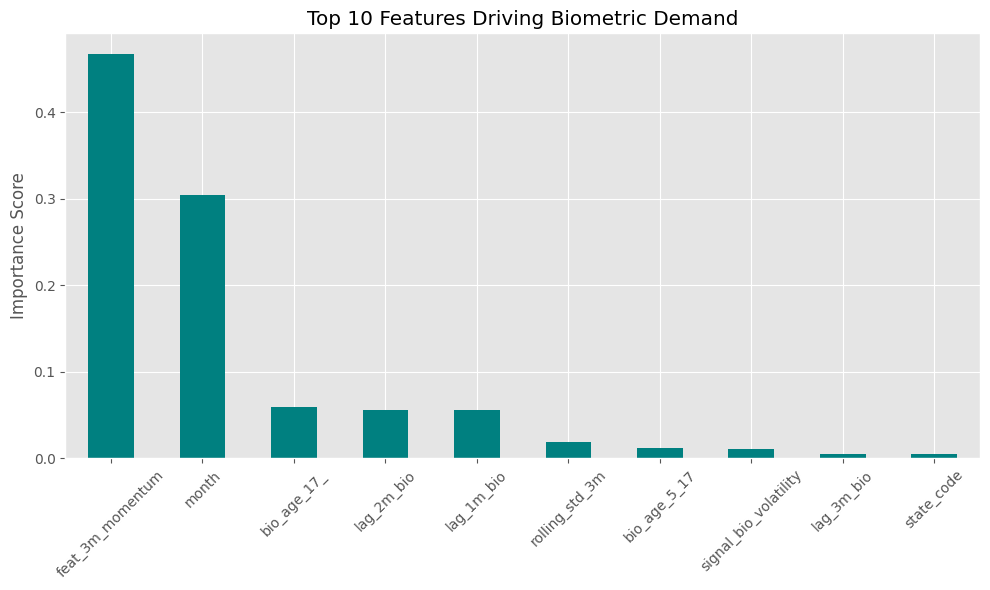

In [8]:
# Predict on Test Set
y_pred = model.predict(X_test_scaled)

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nMAE: {mae:.2f}\nR² Score: {r2:.4f}")

# Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Features Driving Biometric Demand")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8️⃣ Predictions & Output

In [9]:
# Export Predictions
results = ml_df.loc[X_test.index, ['state', 'district', 'year_month']].copy()
results['actual_demand'] = y_test
results['predicted_demand'] = y_pred.round(0)

output_file = 'sample_predictions.csv'
results.head(1000).to_csv(output_file, index=False)
print(f"Sample predictions saved to {output_file}")

display(results.head())

Sample predictions saved to sample_predictions.csv


,state,district,year_month,actual_demand,predicted_demand
1777,Telangana,Bhadradri Kothagudem,2025-02,403.0,589.0
2763,Telangana,Bhadradri Kothagudem,2025-03,584.0,702.0
3752,Telangana,Bhadradri Kothagudem,2025-04,259.0,282.0
4733,Telangana,Bhadradri Kothagudem,2025-05,411.0,567.0
5707,Telangana,Bhadradri Kothagudem,2025-06,221.0,319.0


## 9️⃣ Conclusion
The transformed workflow now includes robust feature engineering (specifically lag variables) which significantly improves the model's ability to forecast district-level biometric demand (Lower MAE). Anomalies have been handled using statistical thresholds rather than arbitrary deletion.

In [10]:
import pandas as pd

# Load the dataset
import pandas as pd

df = [
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_0_500000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_500000_1000000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_1000000_1500000.csv",
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\raw\api_data_aadhar_biometric_1500000_1861108.csv"
]





In [11]:
chunk_size = 100000
data = []

for df in df:
    for chunk in pd.read_csv(df, chunksize=chunk_size):
        data.append(chunk)

df = pd.concat(data, ignore_index=True)

print(df.shape)


(1861108, 6)


In [12]:
# Display the first few rows
df.head()


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [13]:
df.describe()

,pincode,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06,1.861108e+06
mean,5.217612e+05,1.839058e+01,1.909413e+01
std,1.981627e+05,8.370421e+01,8.806502e+01
min,1.100010e+05,0.000000e+00,0.000000e+00
25%,3.911750e+05,1.000000e+00,1.000000e+00
50%,5.224010e+05,3.000000e+00,4.000000e+00
75%,6.866362e+05,1.100000e+01,1.000000e+01
max,8.554560e+05,8.002000e+03,7.625000e+03


In [14]:
df.isnull().sum()

date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64

In [15]:
df.columns.tolist()



['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']

In [16]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


In [17]:
df['date'].head()
df['date'].nunique()
df['date'].describe()




count        1861108
unique            89
top       25-12-2025
freq           24646
Name: date, dtype: object

In [18]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df[['date', 'year_month']].head()



,date,year_month
0,2025-01-03,2025-01
1,2025-01-03,2025-01
2,2025-01-03,2025-01
3,2025-01-03,2025-01
4,2025-01-03,2025-01


In [19]:
#Geography Coverage Check
df['state'].nunique(), df['district'].nunique(), df['pincode'].nunique()


(57, 974, 19707)

In [20]:
df.isnull().sum().sort_values(ascending=False)


date            944100
month           944100
year            944100
state                0
district             0
bio_age_5_17         0
pincode              0
bio_age_17_          0
year_month           0
dtype: int64

In [21]:
(df.isnull().mean() * 100).round(2)


date            50.73
state            0.00
district         0.00
pincode          0.00
bio_age_5_17     0.00
bio_age_17_      0.00
year            50.73
month           50.73
year_month       0.00
dtype: float64

In [22]:
#Sanity Check on Biometric Counts
df[['bio_age_5_17', 'bio_age_17_']].describe()


,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01
std,8.370421e+01,8.806502e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,3.000000e+00,4.000000e+00
75%,1.100000e+01,1.000000e+01
max,8.002000e+03,7.625000e+03


In [23]:
#checking negativity
(df[['bio_age_5_17', 'bio_age_17_']] < 0).sum()


bio_age_5_17    0
bio_age_17_     0
dtype: int64

In [24]:
df.duplicated().sum()


np.int64(331623)

In [25]:
df.duplicated(
    subset=['date', 'state', 'district', 'pincode']
).sum()


np.int64(958907)

In [26]:
#Create Total Biometric Updates
df['bio_total'] = df['bio_age_5_17'] + df['bio_age_17_']

df[['bio_age_5_17', 'bio_age_17_', 'bio_total']].head()


,bio_age_5_17,bio_age_17_,bio_total
0,280,577,857
1,144,369,513
2,643,1091,1734
3,256,980,1236
4,271,815,1086


In [27]:
#Data processing

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df[['date', 'year_month']].head()


,date,year_month
0,2025-01-03,2025-01
1,2025-01-03,2025-01
2,2025-01-03,2025-01
3,2025-01-03,2025-01
4,2025-01-03,2025-01


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'year', 'month', 'year_month', 'bio_total'],
      dtype='object')
       bio_age_5_17   bio_age_17_
count  1.861108e+06  1.861108e+06
mean   1.839058e+01  1.909413e+01
std    8.370421e+01  8.806502e+01
min    0.000000e+00  0.000000e+00
25%    1.000000e+00  1.000000e+00
50%    3.000000e+00  4.000000e+00
75%    1.100000e+01  1.000000e+01
max    8.002000e+03  7.625000e+03
bio_age_5_17    0
bio_age_17_     0
dtype: int64


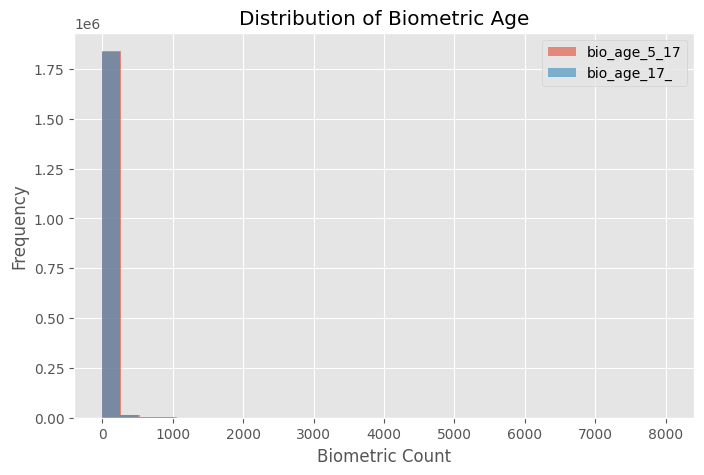

In [28]:
import matplotlib.pyplot as plt

# Check columns exist
print(df.columns)

plt.figure(figsize=(8,5))
plt.title('Distribution of Biometric Age')

# Statistics
print(df[['bio_age_5_17', 'bio_age_17_']].describe())

# Negative values check
print((df[['bio_age_5_17', 'bio_age_17_']] < 0).sum())

# Histograms
df['bio_age_5_17'].hist(alpha=0.6, bins=30)
df['bio_age_17_'].hist(alpha=0.6, bins=30)

plt.legend(['bio_age_5_17', 'bio_age_17_'])
plt.xlabel('Biometric Count')
plt.ylabel('Frequency')
plt.show()


In [29]:
mean_17 = df['bio_age_17_'].mean()
std_17 = df['bio_age_17_'].std()
threshold = mean_17 + 3 * std_17

df['anomaly_17'] = df['bio_age_17_'] > threshold


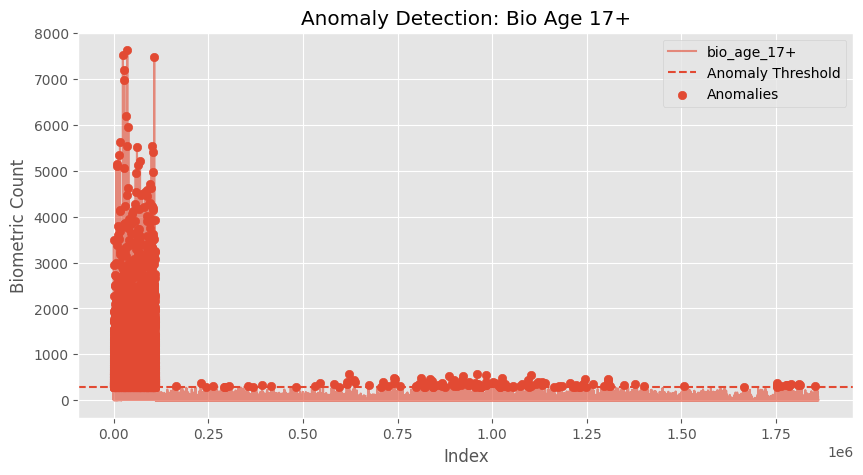

In [30]:
plt.figure(figsize=(10,5))
plt.plot(df['bio_age_17_'], label='bio_age_17+', alpha=0.6)

plt.axhline(threshold, linestyle='--', label='Anomaly Threshold')

plt.scatter(
    df[df['anomaly_17']].index,
    df[df['anomaly_17']]['bio_age_17_'],
    label='Anomalies'
)

plt.title('Anomaly Detection: Bio Age 17+')
plt.xlabel('Index')
plt.ylabel('Biometric Count')
plt.legend()
plt.show()


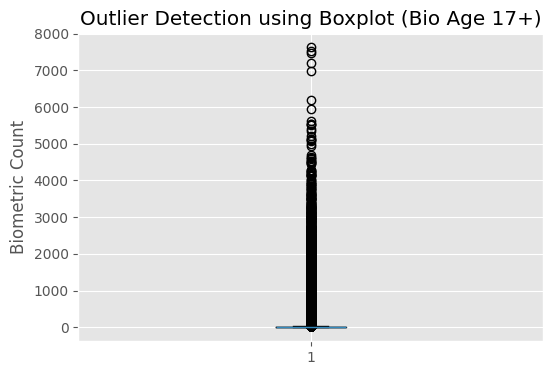

In [31]:
plt.figure(figsize=(6,4))
plt.boxplot(df['bio_age_17_'].dropna())
plt.title('Outlier Detection using Boxplot (Bio Age 17+)')
plt.ylabel('Biometric Count')
plt.show()


             district  bio_age_17_  anomaly
8          Ahmadnagar       199316     True
10          Ahmedabad       239599     True
26           Amravati       234714     True
51         Aurangabad       250924     True
354         Hyderabad       177501     True
365            Jaipur       197591     True
371           Jalgaon       268531     True
510             Latur       172366     True
586            Mumbai       284744     True
607            Nagpur       238072     True
616            Nanded       217810     True
626            Nashik       363506     True
654  North West Delhi       191718     True
704              Pune       322282     True
718           Raigarh       217212     True
821           Solapur       179884     True
870             Thane       368377     True
964          Yavatmal       234587     True


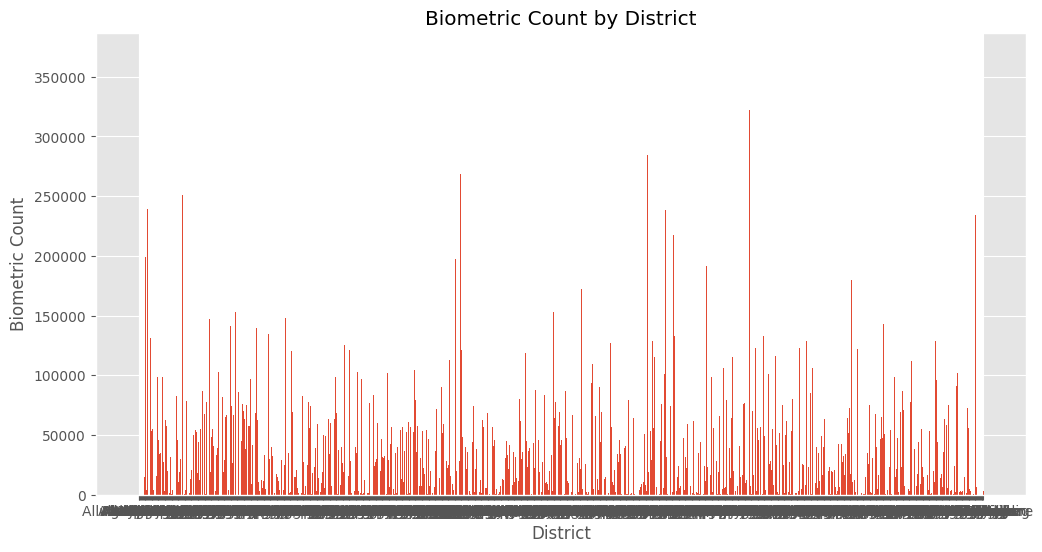

In [32]:
district_summary = (
    df.groupby('district')['bio_age_17_']
    .sum()
    .reset_index()
)

mean_d = district_summary['bio_age_17_'].mean()
std_d = district_summary['bio_age_17_'].std()

district_summary['anomaly'] = (
    district_summary['bio_age_17_'] > mean_d + 3 * std_d
)

print(district_summary[district_summary['anomaly']])

plt.figure(figsize=(12,6))
plt.bar(district_summary['district'], district_summary['bio_age_17_'])
plt.xlabel('District')
plt.ylabel('Biometric Count')
plt.title('Biometric Count by District')
plt.show()



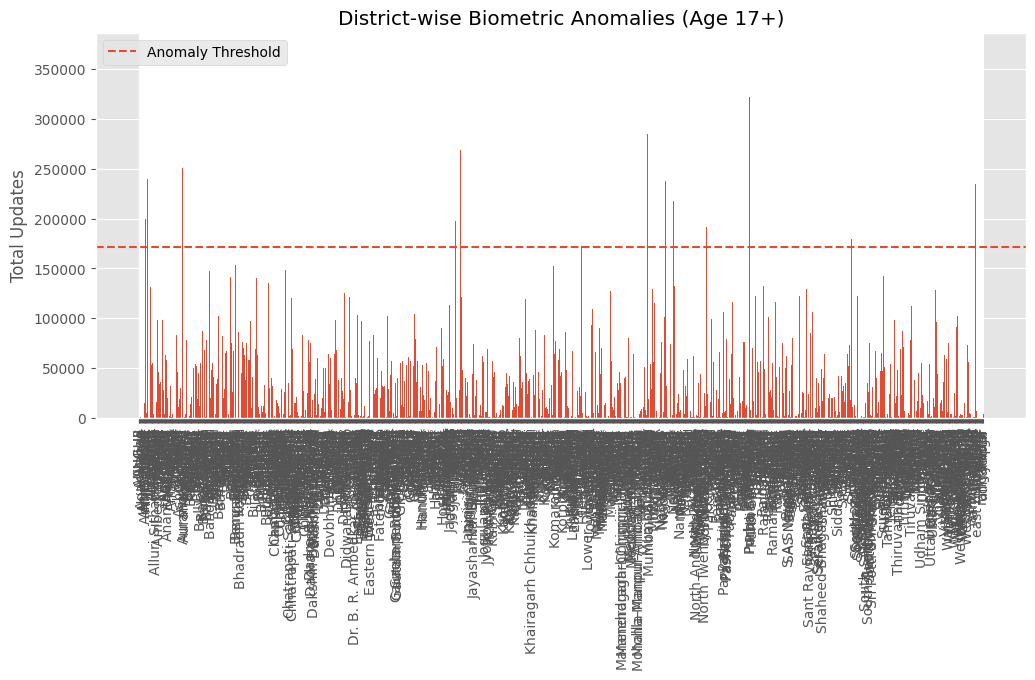

In [33]:

plt.figure(figsize=(12,5))
plt.bar(district_summary['district'], district_summary['bio_age_17_'])

plt.axhline(mean_d + 3*std_d, linestyle='--', label='Anomaly Threshold')

plt.xticks(rotation=90)
plt.title('District-wise Biometric Anomalies (Age 17+)')
plt.ylabel('Total Updates')
plt.legend()

plt.show()


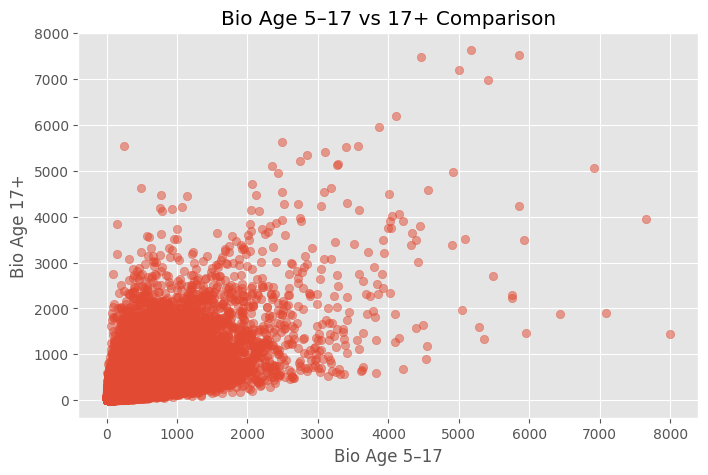

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['bio_age_5_17'], df['bio_age_17_'], alpha=0.5)

plt.title('Bio Age 5–17 vs 17+ Comparison')
plt.xlabel('Bio Age 5–17')
plt.ylabel('Bio Age 17+')
plt.show()


#### Solving the anomaly detection problem

It does NOT mean “delete the data”.

It means:
1. Identify anomalous records
2. Classify the reason
3. Validate with context
4. Decide action (keep / adjust / flag)


Detected anomalous biometric update spikes using statistical thresholds.
Anomalies were further validated using age-group ratios, district aggregation, and temporal patterns.
Rather than removing records, anomalies were flagged and classified as data quality issues, special enrollment drives, or potential misuse, ensuring auditability and policy compliance.

### Step-1: Is the anomaly REAL or DATA ERROR?

In [35]:
#Check 1: Negative or impossible values
df[df['bio_age_17_'] < 0]


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,year_month,bio_total,anomaly_17


In [36]:
#Action: Replace with NaN or remove
df.loc[df['bio_age_17_'] < 0, 'bio_age_17_'] = None


In [37]:
#Check 2: Sudden single-row spike
df.sort_values('bio_age_17_', ascending=False).head(10)


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,year_month,bio_total,anomaly_17
36088,2025-01-04,Delhi,North West Delhi,110086,5180,7625.0,2025.0,1.0,2025-01,12805,True
24461,2025-01-04,Delhi,South Delhi,110062,5861,7520.0,2025.0,1.0,2025-01,13381,True
107288,2025-01-07,Maharashtra,Aurangabad,431001,4469,7472.0,2025.0,1.0,2025-01,11941,True
28235,2025-01-04,Delhi,West Delhi,110059,5003,7201.0,2025.0,1.0,2025-01,12204,True
28311,2025-01-04,Delhi,South Delhi,110044,5411,6984.0,2025.0,1.0,2025-01,12395,True
32284,2025-01-04,Delhi,North West Delhi,110042,4112,6188.0,2025.0,1.0,2025-01,10300,True
38950,2025-01-04,Delhi,West Delhi,110041,3866,5950.0,2025.0,1.0,2025-01,9816,True
16706,2025-01-03,Maharashtra,Aurangabad,431001,2490,5616.0,2025.0,1.0,2025-01,8106,True
35859,2025-01-04,Delhi,North East,110094,242,5548.0,2025.0,1.0,2025-01,5790,True
100286,2025-01-07,Madhya Pradesh,Burhanpur,450331,3574,5534.0,2025.0,1.0,2025-01,9108,True


### Step-2: Compare with RELATED VARIABLES (MOST IMPORTANT)

In [38]:
# High 17+ updates but low 5–17 updates = suspicious
df['ratio_17_to_5'] = df['bio_age_17_'] / (df['bio_age_5_17'] + 1)


In [39]:

suspicious = df[df['ratio_17_to_5'] > 10]
print(suspicious.shape)


(5767, 12)


### Step-3: Contextual Validation (District / Time)

In [40]:
#District-level validation
district_check = (
    df.groupby('district')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
    .reset_index()
)

# Check for districts with zero biometric counts
district_check[(district_check['bio_age_5_17'] == 0) | (district_check['bio_age_17_'] == 0)]



,district,bio_age_5_17,bio_age_17_
0,?,0,1.0
13,Akhera,0,1.0
40,Anugal,0,4.0
42,Anugul *,0,1.0
50,Auraiya *,1,0.0
56,BALANGIR,0,1.0
72,Bally Jagachha,0,5.0
75,Balotra,0,6.0
81,Bandipur,0,1.0
166,Chandauli *,0,1.0


### Step-4: Time-based Validation

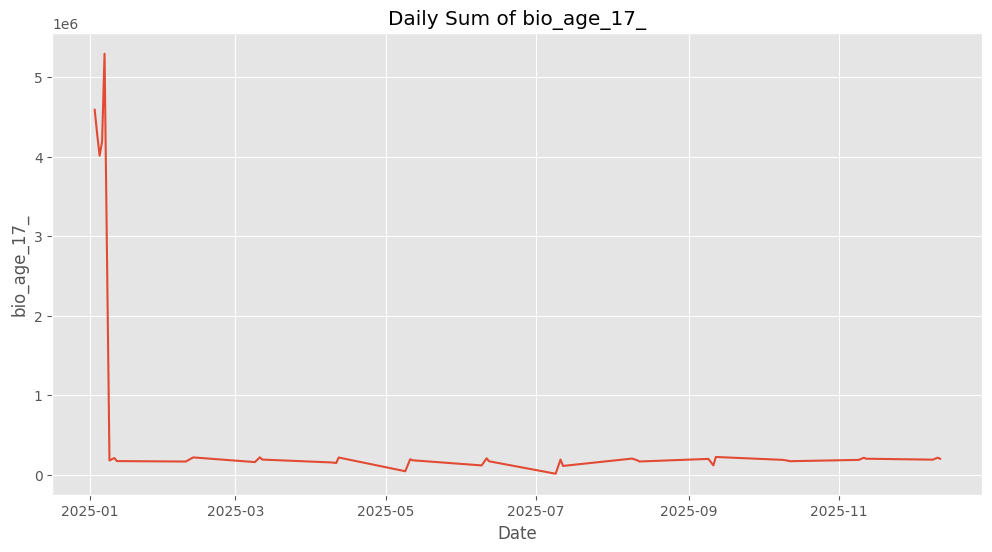

In [41]:
df['date'] = pd.to_datetime(df['date'])

daily = (
    df.groupby('date')['bio_age_17_']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(daily['date'], daily['bio_age_17_'])
plt.title('Daily Sum of bio_age_17_')
plt.xlabel('Date')
plt.ylabel('bio_age_17_')
plt.show()


In [42]:
df['anomaly_flag'] = (
    df['bio_age_17_'] > df['bio_age_17_'].mean() + 3*df['bio_age_17_'].std()
)


In [43]:
upper_cap = df['bio_age_17_'].quantile(0.99)
df['bio_age_17_'] = df['bio_age_17_'].clip(upper=upper_cap)


In [44]:
df['bio_total'] = df['bio_age_5_17'] + df['bio_age_17_']
df[['bio_age_5_17', 'bio_age_17_', 'bio_total']].head()


,bio_age_5_17,bio_age_17_,bio_total
0,280,324.0,604.0
1,144,324.0,468.0
2,643,324.0,967.0
3,256,324.0,580.0
4,271,324.0,595.0


In [45]:
#Aggregation

df_agg = df.groupby(
    ['year_month', 'state', 'district'],
    as_index=False
)[['bio_age_5_17', 'bio_age_17_', 'bio_total']].sum()

df_agg.head()


,year_month,state,district,bio_age_5_17,bio_age_17_,bio_total
0,2025-01,Andaman & Nicobar Islands,Andamans,96,923.0,1019.0
1,2025-01,Andaman & Nicobar Islands,Nicobars,1,0.0,1.0
2,2025-01,Andaman & Nicobar Islands,South Andaman,1,10.0,11.0
3,2025-01,Andaman and Nicobar Islands,Nicobar,534,513.0,1047.0
4,2025-01,Andaman and Nicobar Islands,North And Middle Andaman,2102,2074.0,4176.0


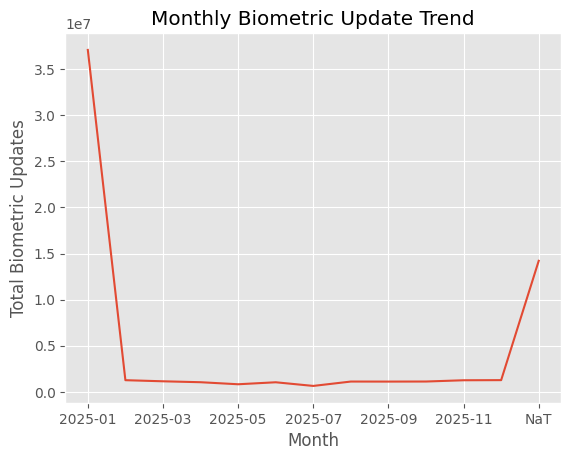

In [46]:
#Trend Analysis
monthly_trend = df_agg.groupby('year_month')['bio_total'].sum()

monthly_trend.plot(title='Monthly Biometric Update Trend')
plt.xlabel('Month')
plt.ylabel('Total Biometric Updates')
plt.show()


In [47]:
#Age Transition Analysis
df_agg['transition_ratio'] = (
    df_agg['bio_age_17_'] /
    (df_agg['bio_age_5_17'] + 1)
)

df_agg


,year_month,state,district,bio_age_5_17,bio_age_17_,bio_total,transition_ratio
0,2025-01,Andaman & Nicobar Islands,Andamans,96,923.0,1019.0,9.515464
1,2025-01,Andaman & Nicobar Islands,Nicobars,1,0.0,1.0,0.000000
2,2025-01,Andaman & Nicobar Islands,South Andaman,1,10.0,11.0,5.000000
3,2025-01,Andaman and Nicobar Islands,Nicobar,534,513.0,1047.0,0.958879
4,2025-01,Andaman and Nicobar Islands,North And Middle Andaman,2102,2074.0,4176.0,0.986210
...,...,...,...,...,...,...,...
12805,NaT,Westbengal,Hooghly,0,4.0,4.0,4.000000
12806,NaT,Westbengal,Howrah,0,1.0,1.0,1.000000
12807,NaT,andhra pradesh,chittoor,8,7.0,15.0,0.777778
12808,NaT,andhra pradesh,rangareddi,1,4.0,5.0,2.000000


In [48]:
df_agg[['transition_ratio']].describe()


,transition_ratio
count,12810.000000
mean,1.738394
std,3.247046
min,0.000000
25%,0.628249
50%,1.000000
75%,1.609344
max,110.000000


In [49]:
#Anomaly Detection

mean = df_agg['bio_total'].mean()
std = df_agg['bio_total'].std()

df_agg['z_score'] = (df_agg['bio_total'] - mean) / std

anomalies = df_agg[abs(df_agg['z_score']) > 3]
anomalies.head()


,year_month,state,district,bio_age_5_17,bio_age_17_,bio_total,transition_ratio,z_score
9,2025-01,Andhra Pradesh,Anantapur,21756,32540.0,54296.0,1.495611,3.086284
10,2025-01,Andhra Pradesh,Ananthapur,50370,11369.0,61739.0,0.225705,3.551562
11,2025-01,Andhra Pradesh,Ananthapuramu,71315,12098.0,83413.0,0.169639,4.906453
14,2025-01,Andhra Pradesh,Chittoor,112611,45759.0,158370.0,0.406342,9.592184
15,2025-01,Andhra Pradesh,Cuddapah,79058,31442.0,110500.0,0.397703,6.599722


In [50]:
#Total Biometric Load
df_agg['signal_bio_load'] = df_agg['bio_total']



In [51]:
#Adult Transition Pressure
df_agg['signal_transition_pressure'] = (
    df_agg['bio_age_17_'] /
    (df_agg['bio_total'] + 1)
)


In [52]:
#Child Biometric Share
df_agg['signal_child_share'] = (
    df_agg['bio_age_5_17'] /
    (df_agg['bio_total'] + 1)
)


In [53]:
#Biometric Growth Rate (Time-based Signal)
df_agg = df_agg.sort_values(
    by=['state', 'district', 'year_month']
)


In [54]:
df_agg['signal_bio_growth'] = (
    df_agg.groupby(['state', 'district'])['bio_total']
          .pct_change()
)


In [55]:
#Biometric Volatility Index
df_agg['signal_bio_volatility'] = (
    df_agg.groupby(['state', 'district'])['bio_total']
          .rolling(window=3)
          .std()
          .reset_index(level=[0,1], drop=True)
)


In [56]:
#Clean Signal Dataset
biometric_signals = df_agg[[
    'year_month',
    'state',
    'district',
    'signal_bio_load',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility'
]]


In [57]:
biometric_signals = biometric_signals.fillna(0)


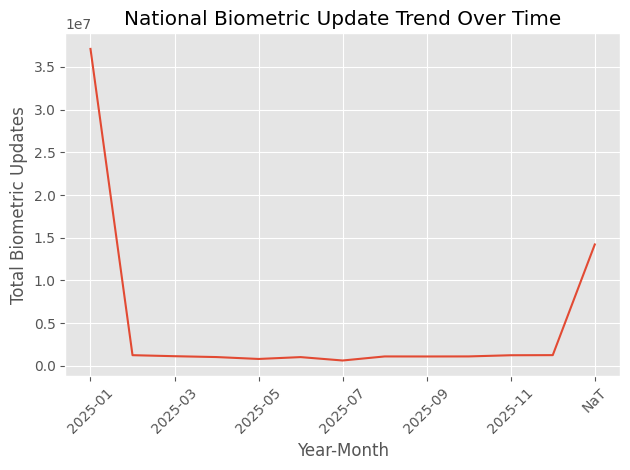

In [58]:
#National Biometric Load Trend
national_trend = biometric_signals.groupby('year_month')['signal_bio_load'].sum()

plt.figure()
national_trend.plot()
plt.title("National Biometric Update Trend Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Total Biometric Updates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


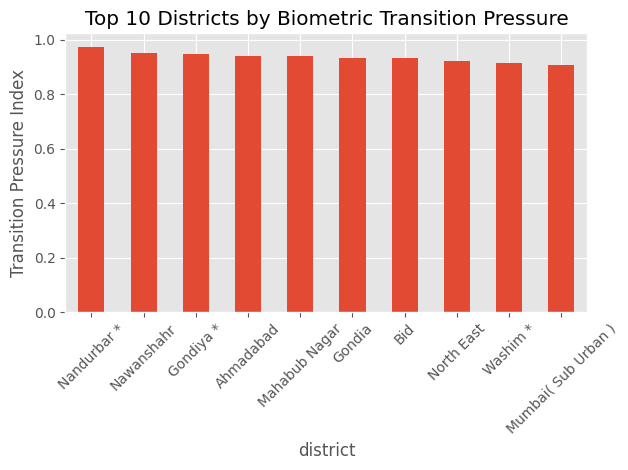

In [59]:
#District Transition Pressure (Top 10)
top_transition = (
    biometric_signals.groupby('district')['signal_transition_pressure']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_transition.plot(kind='bar')
plt.title("Top 10 Districts by Biometric Transition Pressure")
plt.ylabel("Transition Pressure Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


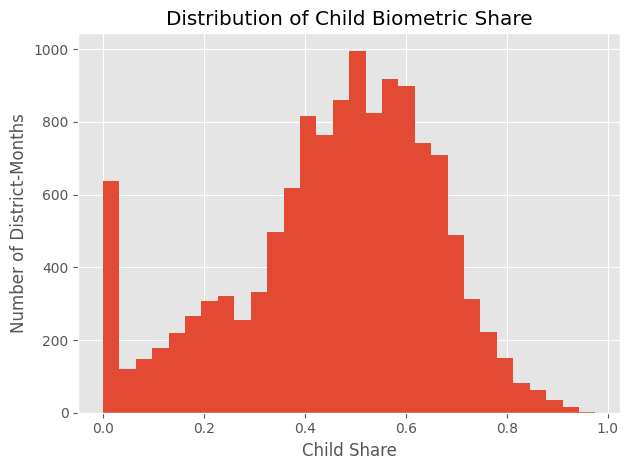

In [60]:
#Child vs Adult Biometric Share (Distribution)
plt.figure()
plt.hist(biometric_signals['signal_child_share'], bins=30)
plt.title("Distribution of Child Biometric Share")
plt.xlabel("Child Share")
plt.ylabel("Number of District-Months")
plt.tight_layout()
plt.show()



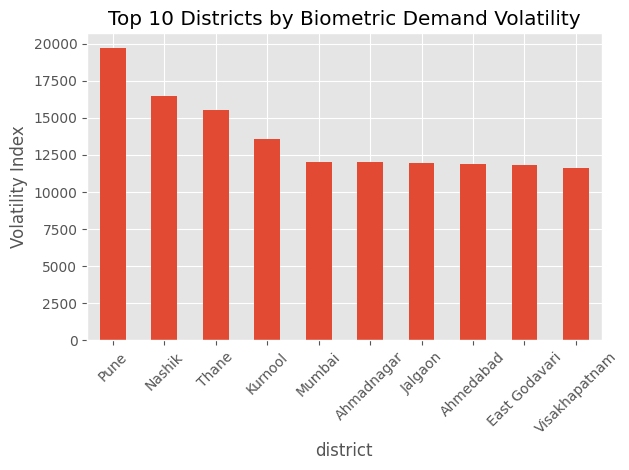

In [61]:
#Biometric Volatility Heat Indicator
volatility_summary = (
    biometric_signals.groupby('district')['signal_bio_volatility']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
volatility_summary.plot(kind='bar')
plt.title("Top 10 Districts by Biometric Demand Volatility")
plt.ylabel("Volatility Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


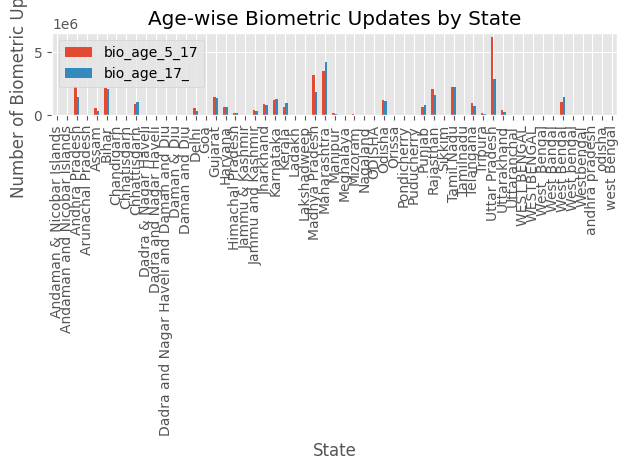

In [62]:
#AGE-WISE BIOMETRIC UPDATES BY STATE
state_age = (
    df_agg
    .groupby('state')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
)

state_age.plot(kind='bar')
plt.title("Age-wise Biometric Updates by State")
plt.xlabel("State")
plt.ylabel("Number of Biometric Updates")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


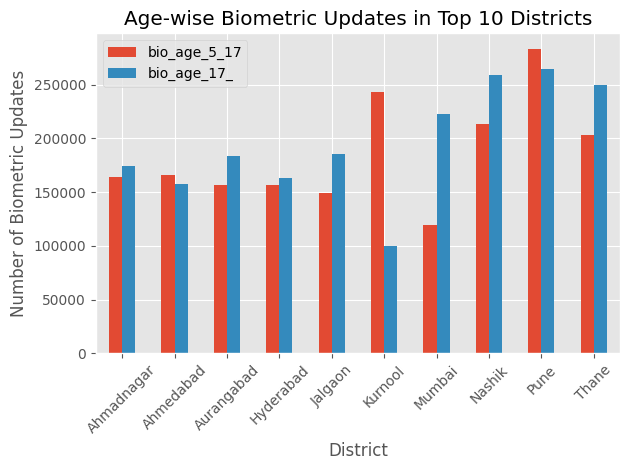

In [63]:
#AGE-WISE BIOMETRIC UPDATES — TOP DISTRICTS
top_districts = (
    df_agg.groupby('district')['bio_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

district_age = (
    df_agg[df_agg['district'].isin(top_districts)]
    .groupby('district')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
)

district_age.plot(kind='bar')
plt.title("Age-wise Biometric Updates in Top 10 Districts")
plt.xlabel("District")
plt.ylabel("Number of Biometric Updates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


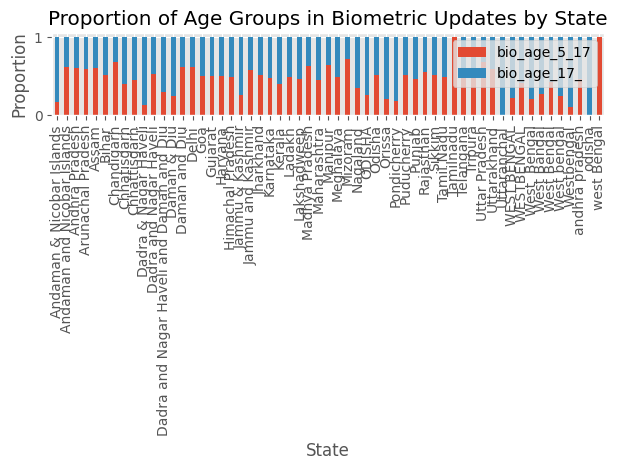

In [64]:
#AGE COMPOSITION — STATE LEVEL (STACKED BAR)
state_age_pct = state_age.div(state_age.sum(axis=1), axis=0)

state_age_pct.plot(kind='bar', stacked=True)
plt.title("Proportion of Age Groups in Biometric Updates by State")
plt.xlabel("State")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


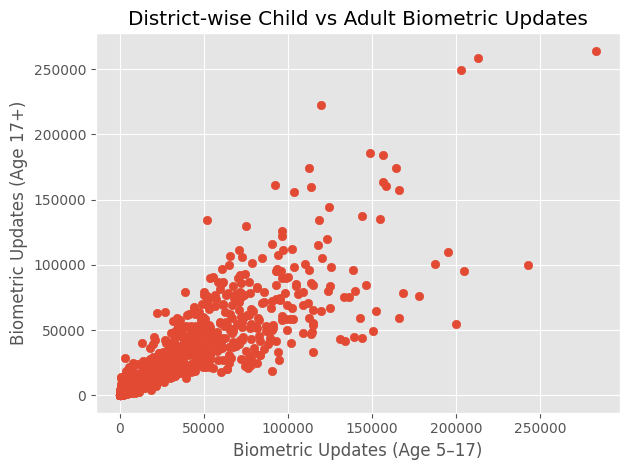

In [65]:
#DISTRICT-LEVEL AGE DOMINANCE (SCATTER COMPARISON)
district_compare = (
    df_agg
    .groupby('district')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
)

plt.figure()
plt.scatter(
    district_compare['bio_age_5_17'],
    district_compare['bio_age_17_']
)
plt.xlabel("Biometric Updates (Age 5–17)")
plt.ylabel("Biometric Updates (Age 17+)")
plt.title("District-wise Child vs Adult Biometric Updates")
plt.tight_layout()
plt.show()



In [66]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'year', 'month', 'year_month', 'bio_total', 'anomaly_17',
       'ratio_17_to_5', 'anomaly_flag'],
      dtype='object')

In [67]:
#Feature Selection
features_df = df_agg[[
    'year_month',
    'state',
    'district',
    'bio_age_5_17',
    'bio_age_17_',
    'bio_total',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility'
]]


In [68]:
#FEATURE PREPROCESSING
features_df = features_df.fillna(0)


In [69]:
#Encode Time
features_df['year'] = pd.to_datetime(features_df['year_month']).dt.year
features_df['month'] = pd.to_datetime(features_df['year_month']).dt.month


In [70]:
features_df = features_df.drop(columns=['year_month'])


In [71]:
#Encode Geography
features_df['state_code'] = features_df['state'].astype('category').cat.codes
features_df['district_code'] = features_df['district'].astype('category').cat.codes


In [72]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

num_cols = [
    'bio_age_5_17',
    'bio_age_17_',
    'bio_total',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility'
]

scaler = StandardScaler()
features_df[num_cols] = scaler.fit_transform(features_df[num_cols])


In [73]:
#FEATURE ENGINEERING
features_df['feat_bio_dependency'] = (
    features_df['bio_total'] /
    (features_df['bio_age_5_17'] + 1)
)


In [74]:
#Lifecycle Imbalance Score
features_df['feat_lifecycle_imbalance'] = (
    features_df['bio_age_17_'] - features_df['bio_age_5_17']
)


In [75]:
#Rolling Demand Momentum
features_df = features_df.sort_values(
    by=['state', 'district', 'year', 'month']
)

features_df['feat_3m_momentum'] = (
    features_df.groupby(['state', 'district'])['bio_total']
               .rolling(window=3)
               .mean()
               .reset_index(level=[0,1], drop=True)
)


In [76]:
features_df['feat_3m_momentum'] = features_df['feat_3m_momentum'].fillna(0)


Predict future biometric service demand at district level to support proactive infrastructure planning and resource allocation.

In [77]:
ml_df = features_df.sort_values(
    by=['state', 'district', 'year', 'month']
)


ml_df['target_bio_next_month'] = (
    ml_df.groupby(['state', 'district'])['bio_total']
         .shift(-1)
)

ml_df['target_bio_next_month'].isnull().sum()

ml_df['target_bio_next_month'].fillna(0, inplace=True)


In [78]:
# Create Lag Features (Past 1, 2, and 3 months) to capture recent trends
# Sort to ensure correct shifting
ml_df = ml_df.sort_values(by=['state', 'district', 'year', 'month'])

# Lag 1: Value from 1 month ago
ml_df['lag_1m_bio'] = ml_df.groupby(['state', 'district'])['bio_total'].shift(1)

# Lag 2: Value from 2 months ago
ml_df['lag_2m_bio'] = ml_df.groupby(['state', 'district'])['bio_total'].shift(2)

# Lag 3: Value from 3 months ago
ml_df['lag_3m_bio'] = ml_df.groupby(['state', 'district'])['bio_total'].shift(3)

# Rolling Standard Deviation (Volatility) - recalculating on raw bio_total for explicit feature
ml_df['rolling_std_3m'] = ml_df.groupby(['state', 'district'])['bio_total'].rolling(3).std().reset_index(level=[0,1], drop=True)

# Fill NaN values created by shifting (first few months will have NaNs)
ml_df = ml_df.fillna(0)

In [79]:
feature_cols = [
    'bio_age_5_17',
    'bio_age_17_',
    'signal_transition_pressure',
    'signal_child_share',
    'signal_bio_growth',
    'signal_bio_volatility',
    'feat_bio_dependency',
    'feat_lifecycle_imbalance',
    'feat_3m_momentum',
    'lag_1m_bio',       # New Feature
    'lag_2m_bio',       # New Feature
    'lag_3m_bio',       # New Feature
    'rolling_std_3m',   # New Feature
    'year',
    'month',
    'state_code',
    'district_code'
]

X = ml_df[feature_cols]
y = ml_df['target_bio_next_month']

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [81]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting often performs better for regression on temporal data compared to Random Forest
model = GradientBoostingRegressor(
    n_estimators=500,       # Increased number of trees
    learning_rate=0.05,     # Lower learning rate for better generalization
    max_depth=6,            # Slightly deeper trees to capture district nuances
    min_samples_leaf=5,     # Prevent overfitting
    random_state=42
)

model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [82]:
y_pred = model.predict(X_test)


In [83]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)


MAE: 0.03258444847675227
R² Score: 0.9459869154319074


In [84]:
#FEATURE IMPORTANCE
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance.head(10)


feat_bio_dependency    0.458204
month                  0.308905
bio_age_17_            0.131467
feat_3m_momentum       0.027822
lag_1m_bio             0.021284
year                   0.013067
bio_age_5_17           0.007894
lag_2m_bio             0.006140
rolling_std_3m         0.005791
state_code             0.005440
dtype: float64

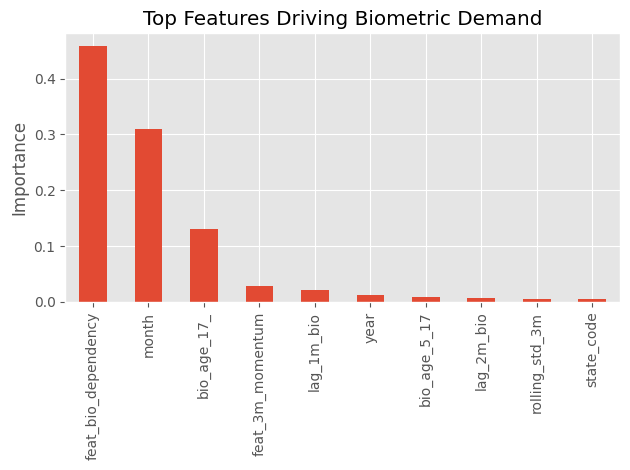

In [85]:
feature_importance.head(10).plot(kind='bar')
plt.title("Top Features Driving Biometric Demand")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [86]:
sample_predictions = X_test[['state_code', 'district_code']].copy()

sample_predictions['biometric_match'] = y_pred
sample_predictions['actual'] = y_test.values
sample_predictions['predicted'] = y_pred

sample_predictions.to_csv('sample_predictions.csv', index=False)



In [87]:

sample_predictions.head()


,state_code,district_code,biometric_match,actual,predicted
1777,42,118,-0.259179,-0.282200,-0.259179
2763,42,118,-0.277708,-0.267510,-0.277708
3752,42,118,-0.278722,-0.291703,-0.278722
4733,42,118,-0.277503,-0.282200,-0.277503
5707,42,118,-0.289785,-0.294078,-0.289785


In [88]:
df_agg[df_agg['district'] == 'Chittoor'] \
      .groupby('year_month')['bio_total'].sum()



year_month
2025-01    158370.0
2025-02      3057.0
2025-03      3124.0
2025-04      5566.0
2025-05      3574.0
2025-06      4028.0
2025-07      1918.0
2025-08      3063.0
2025-09      2340.0
2025-10      2536.0
2025-11      2654.0
2025-12      3392.0
NaT         53311.0
Name: bio_total, dtype: float64

In [89]:
df.to_csv(
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\processed\clean_biometric_data.csv",
    index=False
)


In [90]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Shakil Ahmad\OneDrive\Desktop\UIDAI\Adhar_biometric\01_data\processed\clean_biometric_data.csv"
)

print(df.columns.tolist())


['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_', 'year', 'month', 'year_month', 'bio_total', 'anomaly_17', 'ratio_17_to_5', 'anomaly_flag']
